In [ ]:
!pip install -q shap

In [ ]:
import sys, json, shutil, tarfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

BASE  = Path('/content/drive/MyDrive/Diplom2')
META  = BASE / 'data' / 'meta'
ARC   = BASE / 'data' / 'archives'

CKPT_SIG = BASE / 'checkpoints' / 'resnet50_signals'
CKPT_TAB = BASE / 'checkpoints' / 'resnet50'
for d in (ARC, CKPT_SIG, CKPT_TAB):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(BASE / 'code'))

assert torch.cuda.is_available(), 'GPU runtime required (Colab → Runtime → T4 GPU)'
print('CUDA device:', torch.cuda.get_device_name(0))


Mounted at /content/drive
CUDA device: NVIDIA A100-SXM4-40GB


In [ ]:
LOCAL_SIG = Path('/content/signals_norm.npy')
if not LOCAL_SIG.exists():
    src = ARC / 'normalized.tar'
    print(f'copying {src}  ({src.stat().st_size/1e9:.2f} GB)…')
    shutil.copy(str(src), '/content/normalized.tar')
    with tarfile.open('/content/normalized.tar', 'r') as t:
        t.extractall('/content')
print('signals at', LOCAL_SIG, '|', LOCAL_SIG.stat().st_size / 1e9, 'GB')


copying /content/drive/MyDrive/Diplom2/data/archives/normalized.tar  (16.36 GB)…


/tmp/ipykernel_4584/2379411620.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('/content')


signals at /content/signals_norm.npy | 16.364812928 GB


In [ ]:
from train import train_model, model_predict
from models import ResNet50_1D_ECG
from metrics import compute_metrics, plot_roc, save_metrics

norm_meta   = pd.read_csv(META / 'meta_norm.csv')
feature_cols = pd.read_csv(META / 'feature_cols.csv')['feature'].tolist()

train_df = norm_meta[norm_meta['split'] == 'train'].reset_index(drop=True)
val_df   = norm_meta[norm_meta['split'] == 'val'  ].reset_index(drop=True)
test_df  = norm_meta[norm_meta['split'] == 'test' ].reset_index(drop=True)

print(f'train={len(train_df)}  val={len(val_df)}  test={len(test_df)}')
print(f'n_features={len(feature_cols)}')


/tmp/ipykernel_4584/2959619924.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  norm_meta   = pd.read_csv(META / 'meta_norm.csv')


train=88939  val=14752  test=18071
n_features=205


In [ ]:
_DUMMY = 'dummy_zero'
for df in (train_df, val_df, test_df):
    df[_DUMMY] = 0.0

feature_cols_sig = [_DUMMY]

result_sig = train_model(
    ResNet50_1D_ECG, train_df, val_df, feature_cols_sig,
    signals_path=LOCAL_SIG,
    save_dir=CKPT_SIG,
    epochs=40, batch_size=256, lr=1e-4, num_workers=4,
)


epoch 001 | train=0.6047 | val=0.4652 | auc=0.6264 | best=0.6264 | lr=2.00e-05 | skipped=0
epoch 002 | train=0.4700 | val=0.3264 | auc=0.7047 | best=0.7047 | lr=4.00e-05 | skipped=0
epoch 003 | train=0.4279 | val=0.3661 | auc=0.7536 | best=0.7536 | lr=6.00e-05 | skipped=0
epoch 004 | train=0.4014 | val=0.3899 | auc=0.7714 | best=0.7714 | lr=8.00e-05 | skipped=0
epoch 005 | train=0.3836 | val=0.3215 | auc=0.7826 | best=0.7826 | lr=1.00e-04 | skipped=0
epoch 006 | train=0.3716 | val=0.2987 | auc=0.7929 | best=0.7929 | lr=9.98e-05 | skipped=0
epoch 007 | train=0.3597 | val=0.3365 | auc=0.7725 | best=0.7929 | lr=9.92e-05 | skipped=0
epoch 008 | train=0.3508 | val=0.3063 | auc=0.8059 | best=0.8059 | lr=9.82e-05 | skipped=0
epoch 009 | train=0.3425 | val=0.3588 | auc=0.8123 | best=0.8123 | lr=9.68e-05 | skipped=0
epoch 010 | train=0.3376 | val=0.3147 | auc=0.7961 | best=0.8123 | lr=9.50e-05 | skipped=0
epoch 011 | train=0.3280 | val=0.3783 | auc=0.7988 | best=0.8123 | lr=9.29e-05 | skipped=0

=== ResNet50 signal-only ===
{
  "roc_auc": 0.8219038224913343,
  "auc_pr": 0.28243587878005993,
  "top5_recall": 0.29308909242298087,
  "f1": 0.36064425770308123,
  "precision": 0.311178247734139,
  "recall": 0.42880932556203166,
  "threshold": 0.3652302324771881,
  "n_pos": 1201,
  "n_neg": 16870
}


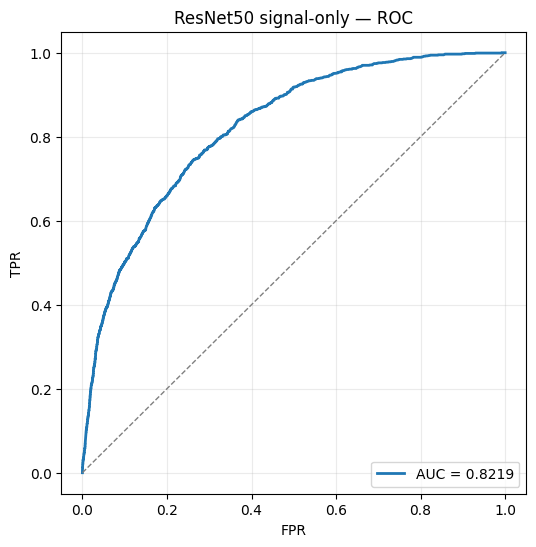

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'ResNet50 signal-only — ROC'}, xlabel='FPR', ylabel='TPR'>)

In [ ]:
ckpt_sig = torch.load(CKPT_SIG / 'best.pt', map_location='cuda')
model_sig = ResNet50_1D_ECG(n_tab_features=1).cuda()
model_sig.load_state_dict(ckpt_sig['model'])

probs_sig, labels = model_predict(model_sig, test_df, feature_cols_sig, LOCAL_SIG)
metrics_sig = compute_metrics(labels, probs_sig)
print('=== ResNet50 signal-only ===')
print(json.dumps(metrics_sig, indent=2))
save_metrics(metrics_sig, CKPT_SIG / 'test_metrics.json')
plot_roc(labels, probs_sig, title='ResNet50 signal-only — ROC',
         savepath=CKPT_SIG / 'roc.png')


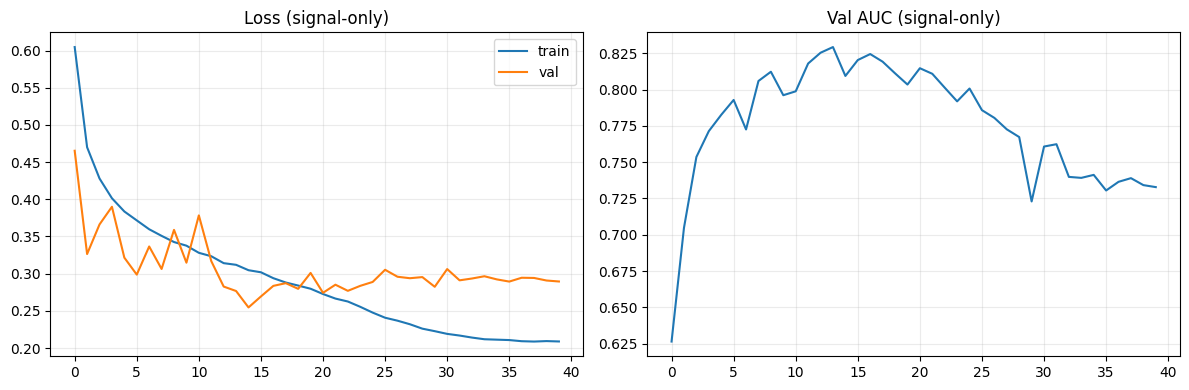

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(result_sig['train_losses'], label='train')
axes[0].plot(result_sig['val_losses'],   label='val')
axes[0].set_title('Loss (signal-only)'); axes[0].legend(); axes[0].grid(alpha=.25)
axes[1].plot(result_sig['val_aucs'])
axes[1].set_title('Val AUC (signal-only)'); axes[1].grid(alpha=.25)
plt.tight_layout()
plt.savefig(CKPT_SIG / 'learning_curves.png', dpi=150); plt.show()


In [ ]:
pd.DataFrame({
    'record_name': test_df.get('record_name', pd.RangeIndex(len(test_df))),
    'chagas_label': labels,
    'resnet50_signal_prob': probs_sig,
}).to_csv(CKPT_SIG / 'test_predictions.csv', index=False)
print('saved', CKPT_SIG / 'test_predictions.csv')


saved /content/drive/MyDrive/Diplom2/checkpoints/resnet50_signals/test_predictions.csv


## 4. Режим 2 — Signal + tabular features

In [ ]:
result_tab = train_model(
    ResNet50_1D_ECG, train_df, val_df, feature_cols,
    signals_path=LOCAL_SIG,
    save_dir=CKPT_TAB,
    epochs=40, batch_size=64, lr=1e-4, num_workers=4,
)


epoch 001 | train=0.5970 | val=0.3999 | auc=0.6612 | best=0.6612 | lr=1.99e-05 | skipped=8
epoch 002 | train=0.4623 | val=0.3941 | auc=0.7450 | best=0.7450 | lr=3.97e-05 | skipped=11
epoch 003 | train=0.4099 | val=0.4583 | auc=0.7285 | best=0.7450 | lr=5.95e-05 | skipped=13
epoch 004 | train=0.3895 | val=0.4293 | auc=0.7744 | best=0.7744 | lr=7.94e-05 | skipped=10
epoch 005 | train=0.3752 | val=0.3402 | auc=0.7915 | best=0.7915 | lr=9.92e-05 | skipped=12
epoch 006 | train=0.3612 | val=0.3061 | auc=0.8086 | best=0.8086 | lr=9.98e-05 | skipped=8
epoch 007 | train=0.3477 | val=0.3014 | auc=0.8140 | best=0.8140 | lr=9.92e-05 | skipped=8
epoch 008 | train=0.3376 | val=0.3581 | auc=0.8347 | best=0.8347 | lr=9.83e-05 | skipped=2
epoch 009 | train=0.3312 | val=0.3157 | auc=0.8387 | best=0.8387 | lr=9.69e-05 | skipped=3
epoch 010 | train=0.3218 | val=0.2605 | auc=0.8582 | best=0.8582 | lr=9.52e-05 | skipped=2
epoch 011 | train=0.3201 | val=0.2454 | auc=0.8548 | best=0.8582 | lr=9.31e-05 | skipp

In [ ]:
ckpt_tab = torch.load(CKPT_TAB / 'best.pt', map_location='cuda')
model_tab = ResNet50_1D_ECG(n_tab_features=len(feature_cols)).cuda()
model_tab.load_state_dict(ckpt_tab['model'])

test_df[feature_cols] = (
    test_df[feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)

probs_tab, _ = model_predict(model_tab, test_df, feature_cols, LOCAL_SIG)
metrics_tab  = compute_metrics(labels, probs_tab)
print(json.dumps(metrics_tab, indent=2))
save_metrics(metrics_tab, CKPT_TAB / 'test_metrics.json')
plot_roc(labels, probs_tab, title='ResNet50 signal+tab — ROC',
         savepath=CKPT_TAB / 'roc.png')

pd.DataFrame({
    'record_name':         test_df.get('record_name', pd.RangeIndex(len(test_df))),
    'chagas_label':        labels,
    'resnet50_tab_prob':   probs_tab,
}).to_csv(CKPT_TAB / 'test_predictions.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(result_tab['train_losses'], label='train')
axes[0].plot(result_tab['val_losses'],   label='val')
axes[0].set_title('Loss (signal+tab)'); axes[0].legend(); axes[0].grid(alpha=.25)
axes[1].plot(result_tab['val_aucs'])
axes[1].set_title('Val AUC (signal+tab)'); axes[1].grid(alpha=.25)
plt.tight_layout()
plt.savefig(CKPT_TAB / 'learning_curves.png', dpi=150); plt.show()


ValueError: Input contains NaN.

In [ ]:
bad = [k for k, v in model_tab.state_dict().items() if not torch.isfinite(v).all()]
print('NaN/Inf в весах:', bad)

NaN/Inf в весах: []


features: shape=(18071, 205), finite=True, min=-1.85e+04, max=9.15e+04
probs_tab: shape=(18071,), NaN/Inf count=1 / 18071
{
  "roc_auc": 0.856086115749225,
  "auc_pr": 0.3544883486903418,
  "top5_recall": 0.3430474604496253,
  "f1": 0.4135618479880775,
  "precision": 0.3742414025623736,
  "recall": 0.4621149042464613,
  "threshold": 0.48011302947998047,
  "n_pos": 1201,
  "n_neg": 16870
}


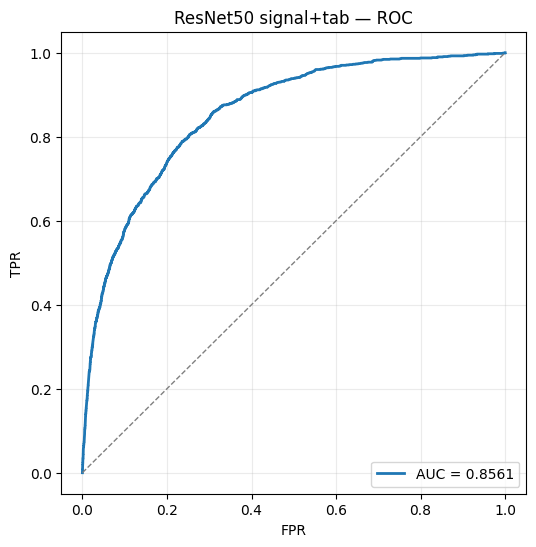

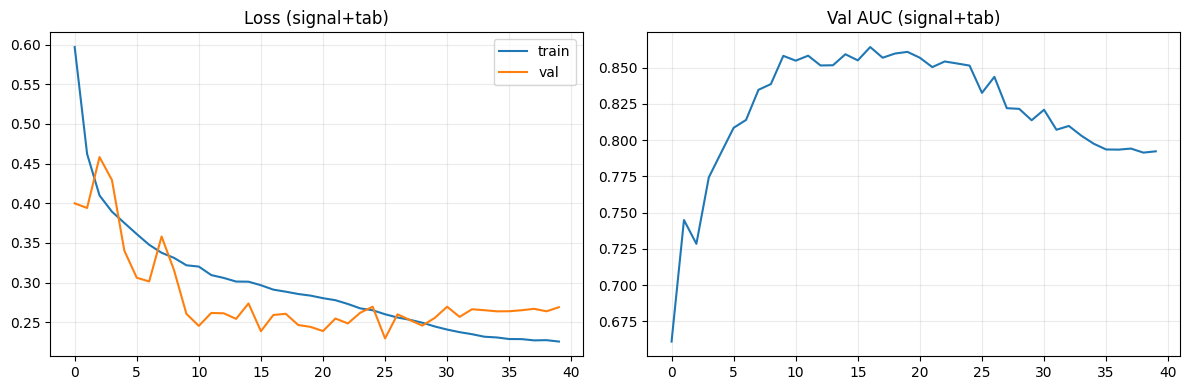

In [ ]:
ckpt_tab = torch.load(CKPT_TAB / 'best.pt', map_location='cuda')
model_tab = ResNet50_1D_ECG(n_tab_features=len(feature_cols)).cuda()
model_tab.load_state_dict(ckpt_tab['model'])

for col in feature_cols:
    test_df[col] = pd.to_numeric(test_df[col], errors='coerce')
test_df[feature_cols] = (
    test_df[feature_cols]
    .astype(np.float32)
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)

arr = test_df[feature_cols].to_numpy(dtype=np.float32)
print(f'features: shape={arr.shape}, finite={np.isfinite(arr).all()}, '
      f'min={arr.min():.3g}, max={arr.max():.3g}')

probs_tab, _ = model_predict(model_tab, test_df, feature_cols, LOCAL_SIG)

nan_mask = ~np.isfinite(probs_tab)
print(f'probs_tab: shape={probs_tab.shape}, NaN/Inf count={nan_mask.sum()} / {len(probs_tab)}')
if nan_mask.any():
    bad_idx = np.where(nan_mask)[0][:5]
    probs_tab = np.nan_to_num(probs_tab, nan=0.5, posinf=1.0, neginf=0.0)

metrics_tab = compute_metrics(labels, probs_tab)
print(json.dumps(metrics_tab, indent=2))
save_metrics(metrics_tab, CKPT_TAB / 'test_metrics.json')
plot_roc(labels, probs_tab, title='ResNet50 signal+tab — ROC',
         savepath=CKPT_TAB / 'roc.png')

pd.DataFrame({
    'record_name':         test_df.get('record_name', pd.RangeIndex(len(test_df))),
    'chagas_label':        labels,
    'resnet50_tab_prob':   probs_tab,
}).to_csv(CKPT_TAB / 'test_predictions.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(result_tab['train_losses'], label='train')
axes[0].plot(result_tab['val_losses'],   label='val')
axes[0].set_title('Loss (signal+tab)'); axes[0].legend(); axes[0].grid(alpha=.25)
axes[1].plot(result_tab['val_aucs'])
axes[1].set_title('Val AUC (signal+tab)'); axes[1].grid(alpha=.25)
plt.tight_layout()
plt.savefig(CKPT_TAB / 'learning_curves.png', dpi=150); plt.show()

\## 5. Сравнение

In [ ]:
compare = pd.DataFrame({
    'model': ['ResNet50 signal-only', 'ResNet50 signal+tab'],
    'ROC-AUC':     [metrics_sig['roc_auc'],     metrics_tab['roc_auc']],
    'AUC-PR':      [metrics_sig['auc_pr'],       metrics_tab['auc_pr']],
    'top5_recall': [metrics_sig['top5_recall'],  metrics_tab['top5_recall']],
    'F1':          [metrics_sig['f1'],           metrics_tab['f1']],
}).set_index('model')
print(compare.to_string())
compare.to_csv(BASE / 'checkpoints' / 'resnet50_comparison.csv')


                       ROC-AUC    AUC-PR  top5_recall        F1
model                                                          
ResNet50 signal-only  0.821904  0.282436     0.293089  0.360644
ResNet50 signal+tab   0.856086  0.354488     0.343047  0.413562



ResNet50 signal-only — lead importance:
lead  mean_abs_shap
   I       0.004640
 aVR       0.004281
 aVL       0.003739
  V4       0.003469
  V2       0.003252
  V3       0.003220
  V5       0.003204
  II       0.003055
  V1       0.003024
  V6       0.003011
 III       0.002931
 aVF       0.002803


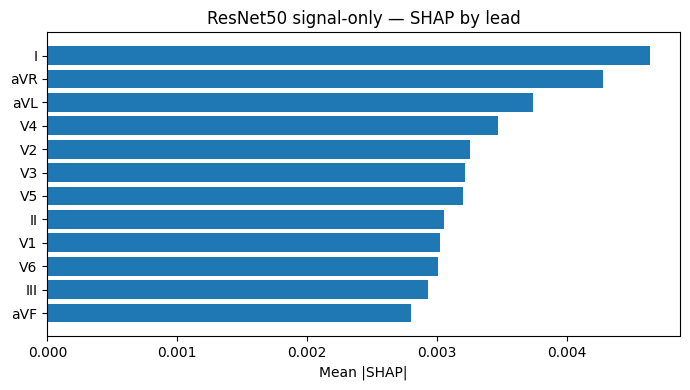


ResNet50 signal+tab — lead importance:
lead  mean_abs_shap
   I       0.011242
 aVR       0.011111
 aVL       0.008960
 III       0.006450
  V6       0.006368
  II       0.006165
  V3       0.005951
  V2       0.005891
  V1       0.005762
  V4       0.005519
 aVF       0.005511
  V5       0.005029


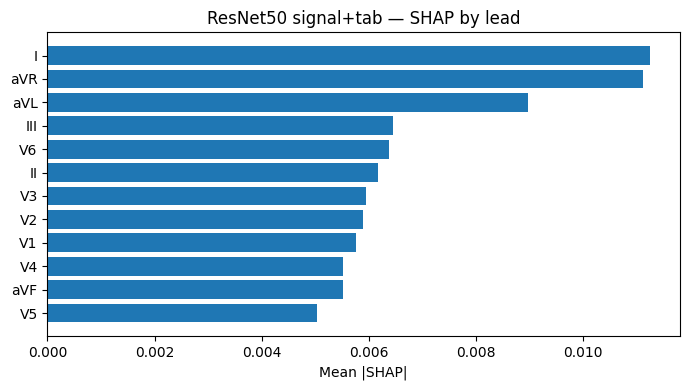

/tmp/ipykernel_4584/237046252.py:65: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_tab_st, ex_tab_vals, feature_names=feature_cols,


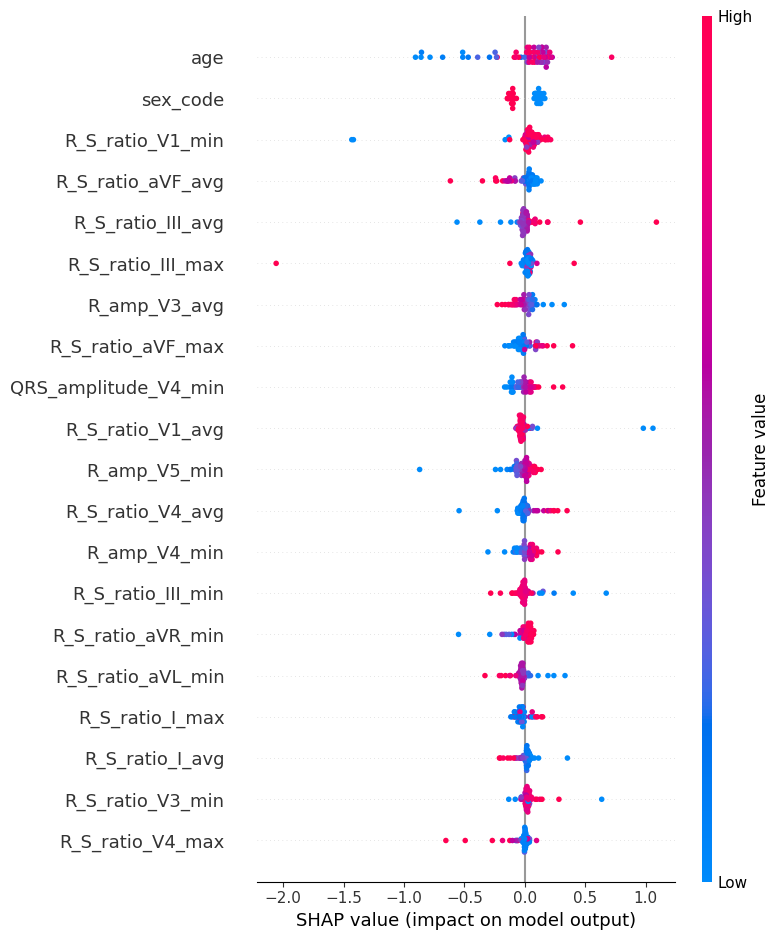

In [ ]:
import shap

LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
signals    = np.load(str(LOCAL_SIG), mmap_mode='r')

N_BG      = 32   # фоновые сэмплы для explainer
N_EXPLAIN = 64   # объясняемые сэмплы

def _load_batch(df, feat_cols, idx_col='norm_idx', device='cuda'):
    """Загружает сигналы + таблицу как тензоры на device."""
    idxs = df[idx_col].astype(int).to_numpy()
    sigs = np.stack([np.asarray(signals[i]).T for i in idxs]).astype(np.float32)
    tabs = df[feat_cols].to_numpy(dtype=np.float32)
    tabs = np.nan_to_num(tabs, nan=0.0)
    return (torch.from_numpy(sigs).to(device),
            torch.from_numpy(tabs).to(device))


def shap_per_lead(model, feat_cols, ckpt_dir, model_name, device='cuda'):
    model.eval()
    rng = np.random.RandomState(0)

    bg_df  = train_df.sample(n=N_BG,      random_state=42).reset_index(drop=True)
    exp_df = test_df .sample(n=N_EXPLAIN,  random_state=42).reset_index(drop=True)

    bg_sig,  bg_tab  = _load_batch(bg_df,  feat_cols, device=device)
    ex_sig,  ex_tab  = _load_batch(exp_df, feat_cols, device=device)

    explainer   = shap.GradientExplainer(model, [bg_sig, bg_tab])
    shap_values = explainer.shap_values([ex_sig, ex_tab])

    shap_sig = np.asarray(shap_values[0])
    shap_tab = np.asarray(shap_values[1])
    if shap_sig.ndim == 4 and shap_sig.shape[-1] == 1:
        shap_sig = shap_sig[..., 0]
    if shap_tab.ndim == 3 and shap_tab.shape[-1] == 1:
        shap_tab = shap_tab[..., 0]

    lead_imp = np.mean(np.abs(shap_sig), axis=(0, 2))   # shape: (12,)
    lead_fi  = pd.DataFrame({'lead': LEAD_NAMES, 'mean_abs_shap': lead_imp})
    lead_fi  = lead_fi.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
    print(f'\n{model_name} — lead importance:')
    print(lead_fi.to_string(index=False))
    lead_fi.to_csv(ckpt_dir / 'shap_lead_importance.csv', index=False)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(lead_fi['lead'].iloc[::-1], lead_fi['mean_abs_shap'].iloc[::-1])
    ax.set_xlabel('Mean |SHAP|'); ax.set_title(f'{model_name} — SHAP by lead')
    plt.tight_layout()
    plt.savefig(ckpt_dir / 'shap_lead_importance.png', dpi=150); plt.show()

    return shap_sig, shap_tab, ex_tab.cpu().numpy()


shap_sig_so, _, _ = shap_per_lead(model_sig, feature_cols_sig, CKPT_SIG,
                                   'ResNet50 signal-only')

shap_sig_st, shap_tab_st, ex_tab_vals = shap_per_lead(model_tab, feature_cols,
                                                        CKPT_TAB, 'ResNet50 signal+tab')

shap.summary_plot(shap_tab_st, ex_tab_vals, feature_names=feature_cols,
                  max_display=20, show=False)
plt.tight_layout()
plt.savefig(CKPT_TAB / 'shap_tabular_summary.png', dpi=150, bbox_inches='tight')
plt.show()
